In [1]:
from __future__ import annotations

import gc
import gzip
import json
import math
import os
import random
import re
import time
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from cooccurrence import (
    build_cooccurrence_matrix,
    build_vocabulary,
    cosine_similarity,
    most_similar,
)

SEED = 42
MAX_DOCUMENTS = 10_000
MIN_COUNT = 2
EPOCHS = 10
WORKERS = max(1, min(4, os.cpu_count() or 1))

random.seed(SEED)
np.random.seed(SEED)

LAB_DIR = Path.cwd()
DATA_PATH = LAB_DIR.parent / "c4-train.00000-of-01024-30K.json.gz"
RESULTS_PATH = LAB_DIR / "results.csv"
assert DATA_PATH.exists(), f"Không tìm thấy corpus: {DATA_PATH}"

TOKEN_PATTERN = re.compile(r"[a-z]+(?:'[a-z]+)?|[0-9]+(?:[.,][0-9]+)?")
SENTENCE_SPLIT_PATTERN = re.compile(r"(?<=[.!?])\s+|\n+")


def tokenize(text: str) -> list[str]:
    return TOKEN_PATTERN.findall(text.lower())


def document_to_sentences(text: str) -> list[list[str]]:
    return [tokens for part in SENTENCE_SPLIT_PATTERN.split(text)
            if (tokens := tokenize(part))]


def load_documents(path: Path, limit: int) -> list[str]:
    documents = []
    with gzip.open(path, "rt", encoding="utf-8") as stream:
        for line in stream:
            item = json.loads(line)
            text = item.get("text", "").strip()
            if text:
                documents.append(text)
            if len(documents) >= limit:
                break
    return documents


print("LAB 03 - Word Representations and Embeddings")
print(f"Corpus file: {DATA_PATH.name}")
print(f"Seed={SEED}, max_documents={MAX_DOCUMENTS:,}, workers={WORKERS}")


LAB 03 - Word Representations and Embeddings
Corpus file: c4-train.00000-of-01024-30K.json.gz
Seed=42, max_documents=10,000, workers=4


In [2]:
print("10. EXPERIMENT 1 - WORD-CONTEXT REPRESENTATION")

toy_corpus = [
    tokenize("the doctor treated the patient"),
    tokenize("the physician treated the patient"),
    tokenize("the doctor works at the hospital"),
    tokenize("the physician works at the hospital"),
    tokenize("the hospital provides medical treatment"),
    tokenize("the cat eats fish"),
    tokenize("the dog eats fish"),
    tokenize("the cat likes milk"),
    tokenize("the dog likes meat"),
    tokenize("a computer processes digital information"),
    tokenize("a football team plays a match"),
    tokenize("a banana is a yellow fruit"),
]

toy_vocab, toy_index_to_word = build_vocabulary(toy_corpus)
toy_matrices = {
    window: build_cooccurrence_matrix(toy_corpus, toy_vocab, window_size=window)
    for window in (1, 2, 5)
}

cooccurrence_stats = pd.DataFrame([
    {
        "window": window,
        "vocabulary_size": len(toy_vocab),
        "matrix_rows": matrix.shape[0],
        "matrix_columns": matrix.shape[1],
        "matrix_entries": matrix.shape[0] * matrix.shape[1],
        "non_zero_values": matrix.nnz,
        "density": matrix.nnz / (matrix.shape[0] * matrix.shape[1]),
    }
    for window, matrix in toy_matrices.items()
])
display(cooccurrence_stats.style.format({"density": "{:.4%}"}))

cooccurrence_pairs = [
    ("doctor", "physician"),
    ("doctor", "hospital"),
    ("cat", "dog"),
]
cooccurrence_similarity_rows = []
for window, matrix in toy_matrices.items():
    for word_a, word_b in cooccurrence_pairs:
        cooccurrence_similarity_rows.append({
            "window": window,
            "word_a": word_a,
            "word_b": word_b,
            "similarity": cosine_similarity(
                matrix.getrow(toy_vocab[word_a]),
                matrix.getrow(toy_vocab[word_b]),
            ),
        })
cooccurrence_similarity_table = pd.DataFrame(cooccurrence_similarity_rows)
display(cooccurrence_similarity_table.pivot(
    index=["word_a", "word_b"], columns="window", values="similarity"
).style.format("{:.4f}"))

cooccurrence_neighbor_rows = []
for window, matrix in toy_matrices.items():
    for query in ("doctor", "physician", "hospital", "cat", "dog"):
        for rank, (neighbor, score) in enumerate(
            most_similar(query, matrix, toy_vocab, top_k=5), start=1
        ):
            cooccurrence_neighbor_rows.append({
                "window": window,
                "query": query,
                "rank": rank,
                "neighbor": neighbor,
                "similarity": score,
            })
cooccurrence_neighbors = pd.DataFrame(cooccurrence_neighbor_rows)
display(cooccurrence_neighbors[cooccurrence_neighbors["query"] == "doctor"].style.format(
    {"similarity": "{:.4f}"}
))


10. EXPERIMENT 1 - WORD-CONTEXT REPRESENTATION


,window,vocabulary_size,matrix_rows,matrix_columns,matrix_entries,non_zero_values,density
0,1,31,31,31,961,74,7.7003%
1,2,31,31,31,961,118,12.2789%
2,5,31,31,31,961,158,16.4412%


,window,query,rank,neighbor,similarity
0,1,doctor,1,physician,1.0000
1,1,doctor,2,at,0.8660
2,1,doctor,3,patient,0.8165
3,1,doctor,4,hospital,0.7746
4,1,doctor,5,cat,0.6667
25,2,doctor,1,physician,1.0000
26,2,doctor,2,works,0.8616
27,2,doctor,3,hospital,0.8199
28,2,doctor,4,patient,0.8165
29,2,doctor,5,treated,0.7385


In [3]:
print("11. CORE IMPLEMENTATION VERIFICATION")

assert len(toy_vocab) == len(toy_index_to_word)
assert toy_matrices[1].shape == (len(toy_vocab), len(toy_vocab))
assert np.allclose(toy_matrices[1].toarray(), toy_matrices[1].toarray().T)
assert math.isclose(cosine_similarity(np.array([1, 0]), np.array([2, 0])), 1.0)
assert most_similar("doctor", toy_matrices[1], toy_vocab, top_k=3)

core_verification = pd.DataFrame([
    {"function": "build_vocabulary", "verification": "vocabulary/index sizes agree", "passed": True},
    {"function": "build_cooccurrence_matrix", "verification": "shape and symmetry checks", "passed": True},
    {"function": "cosine_similarity", "verification": "parallel-vector cosine equals 1", "passed": True},
    {"function": "most_similar", "verification": "returns ranked neighbors", "passed": True},
])
display(core_verification)


11. CORE IMPLEMENTATION VERIFICATION


,function,verification,passed
0,build_vocabulary,vocabulary/index sizes agree,True
1,build_cooccurrence_matrix,shape and symmetry checks,True
2,cosine_similarity,parallel-vector cosine equals 1,True
3,most_similar,returns ranked neighbors,True


In [4]:
print("17. EXPERIMENT 2 - CORPUS PREPARATION")

start = time.perf_counter()
documents = load_documents(DATA_PATH, MAX_DOCUMENTS)
random.Random(SEED).shuffle(documents)
sentences = [
    sentence
    for document in documents
    for sentence in document_to_sentences(document)
    if 2 <= len(sentence) <= 60
]
del documents
gc.collect()

token_counts = Counter(token for sentence in sentences for token in sentence)
corpus_summary = pd.DataFrame([{
    "corpus": DATA_PATH.name,
    "documents": MAX_DOCUMENTS,
    "sentences": len(sentences),
    "tokens": sum(map(len, sentences)),
    "raw_vocabulary": len(token_counts),
    "min_count": MIN_COUNT,
    "word2vec_vocabulary": sum(count >= MIN_COUNT for count in token_counts.values()),
    "load_seconds": time.perf_counter() - start,
}])
display(corpus_summary.style.format({"load_seconds": "{:.2f}"}))

required_words = [
    "doctor", "physician", "hospital", "patient", "disease", "computer",
    "football", "banana", "car", "automobile", "king", "queen", "man",
    "woman", "paris", "france", "italy", "rome", "cat", "dog",
]
required_word_counts = pd.DataFrame([
    {"word": word, "count": token_counts[word], "passes_min_count": token_counts[word] >= MIN_COUNT}
    for word in required_words
])
display(required_word_counts)


17. EXPERIMENT 2 - CORPUS PREPARATION


,corpus,documents,sentences,tokens,raw_vocabulary,min_count,word2vec_vocabulary,load_seconds
0,c4-train.00000-of-01024-30K.json.gz,10000,202766,3567393,96415,2,52578,3.09


,word,count,passes_min_count
0,doctor,274,True
1,physician,86,True
2,hospital,346,True
3,patient,334,True
4,disease,360,True
5,computer,594,True
6,football,512,True
7,banana,41,True
8,car,1103,True
9,automobile,20,True


In [5]:
print("17. EXPERIMENT 2 - WORD2VEC TRAINING")

model_configs = [
    {"model_id": "w2_d100", "window": 2, "vector_size": 100},
    {"model_id": "w5_d50", "window": 5, "vector_size": 50},
    {"model_id": "w5_d100", "window": 5, "vector_size": 100},
    {"model_id": "w5_d300", "window": 5, "vector_size": 300},
    {"model_id": "w10_d100", "window": 10, "vector_size": 100},
]

models = {}
model_summary_rows = []
for config in model_configs:
    start = time.perf_counter()
    model = Word2Vec(
        sentences=sentences,
        vector_size=config["vector_size"],
        window=config["window"],
        min_count=MIN_COUNT,
        workers=WORKERS,
        sg=1,
        hs=0,
        negative=5,
        epochs=EPOCHS,
        seed=SEED,
        sorted_vocab=1,
    )
    elapsed = time.perf_counter() - start
    models[config["model_id"]] = model
    weight_bytes = model.wv.vectors.nbytes + model.syn1neg.nbytes
    model_summary_rows.append({
        **config,
        "corpus": DATA_PATH.name,
        "vocabulary_size": len(model.wv),
        "min_count": MIN_COUNT,
        "epochs": EPOCHS,
        "training_objective": "skip-gram with negative sampling",
        "negative_samples": 5,
        "workers": WORKERS,
        "training_seconds": elapsed,
        "weight_size_mb": weight_bytes / (1024 ** 2),
    })
    print(
        f"{config['model_id']}: vocab={len(model.wv):,}, "
        f"time={elapsed:.2f}s, weights={weight_bytes / (1024 ** 2):.2f}MB"
    )

model_summary = pd.DataFrame(model_summary_rows)
display(model_summary.style.format({
    "training_seconds": "{:.2f}",
    "weight_size_mb": "{:.2f}",
}))


17. EXPERIMENT 2 - WORD2VEC TRAINING


w2_d100: vocab=52,578, time=31.65s, weights=40.11MB


w5_d50: vocab=52,578, time=42.09s, weights=20.06MB


w5_d100: vocab=52,578, time=46.17s, weights=40.11MB


w5_d300: vocab=52,578, time=96.49s, weights=120.34MB


w10_d100: vocab=52,578, time=74.77s, weights=40.11MB


,model_id,window,vector_size,corpus,vocabulary_size,min_count,epochs,training_objective,negative_samples,workers,training_seconds,weight_size_mb
0,w2_d100,2,100,c4-train.00000-of-01024-30K.json.gz,52578,2,10,skip-gram with negative sampling,5,4,31.65,40.11
1,w5_d50,5,50,c4-train.00000-of-01024-30K.json.gz,52578,2,10,skip-gram with negative sampling,5,4,42.09,20.06
2,w5_d100,5,100,c4-train.00000-of-01024-30K.json.gz,52578,2,10,skip-gram with negative sampling,5,4,46.17,40.11
3,w5_d300,5,300,c4-train.00000-of-01024-30K.json.gz,52578,2,10,skip-gram with negative sampling,5,4,96.49,120.34
4,w10_d100,10,100,c4-train.00000-of-01024-30K.json.gz,52578,2,10,skip-gram with negative sampling,5,4,74.77,40.11


In [6]:
print("18. INSPECT EMBEDDINGS AND CORPUS EVIDENCE")

baseline = models["w5_d100"]
inspect_words = ["doctor", "hospital", "patient", "disease", "computer", "football", "banana"]
inspect_rows = []
for query in inspect_words:
    if query not in baseline.wv:
        inspect_rows.append({"query": query, "rank": np.nan, "neighbor": "<OOV>", "similarity": np.nan})
        continue
    for rank, (neighbor, score) in enumerate(baseline.wv.most_similar(query, topn=5), start=1):
        inspect_rows.append({
            "query": query,
            "rank": rank,
            "neighbor": neighbor,
            "similarity": score,
            "query_frequency": token_counts[query],
            "neighbor_frequency": token_counts[neighbor],
        })
inspect_neighbors = pd.DataFrame(inspect_rows)
display(inspect_neighbors.style.format({"similarity": "{:.4f}"}, na_rep="OOV"))

doctor_neighbors = set(
    inspect_neighbors.loc[inspect_neighbors["query"] == "doctor", "neighbor"]
)


def build_context_profiles(
    terms: set[str], corpus: list[list[str]], window: int = 5
) -> dict[str, Counter]:
    profiles = {term: Counter() for term in terms}
    for sentence in corpus:
        for index, token in enumerate(sentence):
            if token not in profiles:
                continue
            left = max(0, index - window)
            right = min(len(sentence), index + window + 1)
            profiles[token].update(
                sentence[position]
                for position in range(left, right)
                if position != index
                and sentence[position] not in ENGLISH_STOP_WORDS
                and len(sentence[position]) > 2
            )
    return profiles


doctor_context_profiles = build_context_profiles({"doctor"} | doctor_neighbors, sentences, window=5)
evidence = {
    neighbor: {"same_sentence_count": 0, "within_window_5_count": 0, "examples": []}
    for neighbor in doctor_neighbors
}
for sentence in sentences:
    if "doctor" not in sentence:
        continue
    sentence_set = set(sentence)
    doctor_positions = [i for i, token in enumerate(sentence) if token == "doctor"]
    for neighbor in doctor_neighbors & sentence_set:
        evidence[neighbor]["same_sentence_count"] += 1
        neighbor_positions = [i for i, token in enumerate(sentence) if token == neighbor]
        evidence[neighbor]["within_window_5_count"] += sum(
            abs(i - j) <= 5 for i in doctor_positions for j in neighbor_positions
        )
        if len(evidence[neighbor]["examples"]) < 3:
            evidence[neighbor]["examples"].append(" ".join(sentence))

doctor_corpus_evidence = pd.DataFrame([
    {
        "query": "doctor",
        "neighbor": neighbor,
        "same_sentence_count": values["same_sentence_count"],
        "within_window_5_count": values["within_window_5_count"],
        "shared_context_count": sum(
            (doctor_context_profiles["doctor"] & doctor_context_profiles[neighbor]).values()
        ),
        "shared_contexts": " | ".join(
            f"{context}:{count}"
            for context, count in (
                doctor_context_profiles["doctor"] & doctor_context_profiles[neighbor]
            ).most_common(10)
        ),
        "doctor_top_contexts": " | ".join(
            f"{context}:{count}"
            for context, count in doctor_context_profiles["doctor"].most_common(10)
        ),
        "neighbor_top_contexts": " | ".join(
            f"{context}:{count}"
            for context, count in doctor_context_profiles[neighbor].most_common(10)
        ),
        "example_contexts": " || ".join(values["examples"]),
    }
    for neighbor, values in evidence.items()
]).sort_values(["shared_context_count", "within_window_5_count"], ascending=False)
display(doctor_corpus_evidence)


18. INSPECT EMBEDDINGS AND CORPUS EVIDENCE


,query,rank,neighbor,similarity,query_frequency,neighbor_frequency
0,doctor,1,surgeon,0.7572,274,117
1,doctor,2,dentist,0.7203,274,51
2,doctor,3,physician,0.7095,274,86
3,doctor,4,ophthalmologist,0.6949,274,10
4,doctor,5,veterinarian,0.6912,274,20
5,hospital,1,icu,0.6310,346,6
6,hospital,2,clinic,0.6258,346,111
7,hospital,3,rehab,0.6253,346,26
8,hospital,4,psychiatric,0.6245,346,14
9,hospital,5,uc,0.6226,346,22


,query,neighbor,same_sentence_count,within_window_5_count,shared_context_count,shared_contexts,doctor_top_contexts,neighbor_top_contexts,example_contexts
4,doctor,surgeon,6,2,131,eye:18 | ask:6 | lasik:6 | speak:4 | surgery:4...,eye:18 | talk:9 | care:9 | health:8 | need:8 |...,lasik:22 | eye:20 | surgery:7 | plastic:6 | as...,over the next two days i saw my first eye doct...
0,doctor,physician,0,0,112,care:9 | medical:6 | health:5 | advice:4 | sai...,eye:18 | talk:9 | care:9 | health:8 | need:8 |...,care:12 | medical:6 | health:5 | family:4 | in...,
3,doctor,dentist,1,1,54,visit:4 | important:3 | best:2 | tell:2 | reco...,eye:18 | talk:9 | care:9 | health:8 | need:8 |...,visit:4 | dental:3 | visiting:3 | cavities:3 |...,talk with your doctor and dentist before the v...
2,doctor,veterinarian,0,0,23,visit:2 | consult:2 | use:1 | visits:1 | make:...,eye:18 | talk:9 | care:9 | health:8 | need:8 |...,consult:2 | visit:2 | animal:2 | elliott:2 | p...,
1,doctor,ophthalmologist,0,0,17,tell:2 | speak:1 | talk:1 | effective:1 | visi...,eye:18 | talk:9 | care:9 | health:8 | need:8 |...,depth:2 | tell:2 | discussion:1 | opt:1 | talk...,


19. EXPERIMENT 3 - CONTEXT WINDOW


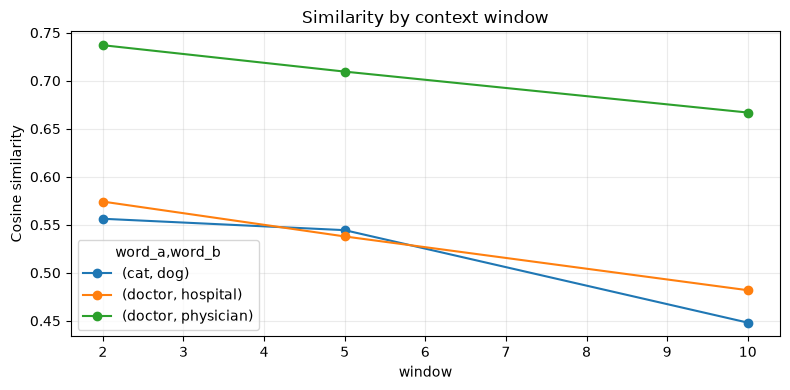

In [7]:
print("19. EXPERIMENT 3 - CONTEXT WINDOW")

window_pairs = [
    ("doctor", "physician"),
    ("doctor", "hospital"),
    ("cat", "dog"),
]
window_model_ids = {2: "w2_d100", 5: "w5_d100", 10: "w10_d100"}
window_similarity_rows = []
for window, model_id in window_model_ids.items():
    model = models[model_id]
    for word_a, word_b in window_pairs:
        score = model.wv.similarity(word_a, word_b) if {word_a, word_b} <= set(model.wv.key_to_index) else np.nan
        window_similarity_rows.append({
            "window": window,
            "model_id": model_id,
            "word_a": word_a,
            "word_b": word_b,
            "similarity": score,
        })
window_similarity = pd.DataFrame(window_similarity_rows)
window_pivot = window_similarity.pivot(index=["word_a", "word_b"], columns="window", values="similarity")
display(window_pivot.style.format("{:.4f}", na_rep="OOV"))

ax = window_pivot.T.plot(marker="o", figsize=(8, 4), title="Similarity by context window")
ax.set_ylabel("Cosine similarity")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


20. EXPERIMENT 4 - EMBEDDING DIMENSION


,dimension,model_id,training_seconds,weight_size_mb,doctor_physician_similarity,doctor_hospital_similarity,analogy_expected,analogy_top1,analogy_top1_score,analogy_expected_rank_at_10,downstream_accuracy_at_1,downstream_mrr
0,50,w5_d50,42.09,20.06,0.8478,0.6983,queen,queen,0.7365,1,100.00%,1.0000
1,100,w5_d100,46.17,40.11,0.7095,0.5379,queen,queen,0.5656,1,100.00%,1.0000
2,300,w5_d300,96.49,120.34,0.5822,0.4159,queen,queen,0.4731,1,100.00%,1.0000


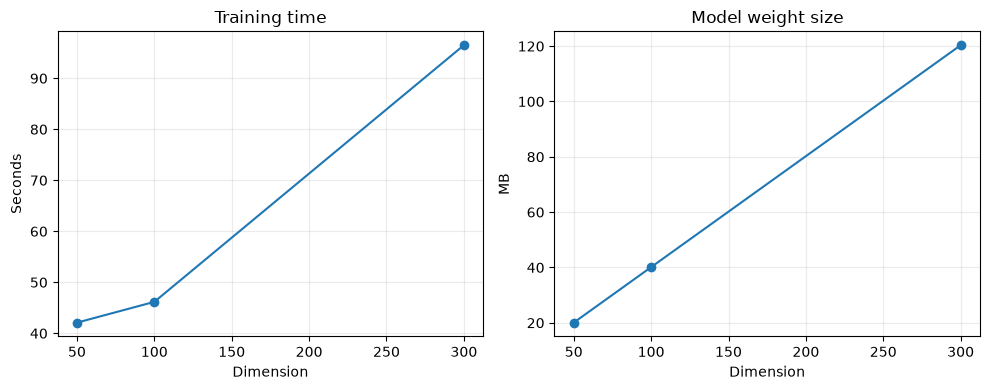

In [8]:
print("20. EXPERIMENT 4 - EMBEDDING DIMENSION")

search_documents = {
    "D1": "a doctor provides medical treatment to a patient in a hospital",
    "D2": "clinical therapy can help treat a serious disease",
    "D3": "a mechanic repairs a car and automobile engine",
    "D4": "the football team won the game and match",
    "D5": "a banana is a yellow fruit rich in nutrients",
    "D6": "computer software processes digital information",
}
search_queries = {
    "medical treatment": "D1",
    "car repair": "D3",
    "football game": "D4",
    "computer software": "D6",
}


def mean_embedding(text: str, model: Word2Vec) -> np.ndarray | None:
    vectors = [model.wv[token] for token in tokenize(text) if token in model.wv]
    return np.mean(vectors, axis=0) if vectors else None


def cosine_dense(a: np.ndarray | None, b: np.ndarray | None) -> float:
    if a is None or b is None:
        return float("nan")
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denominator) if denominator else float("nan")


def rank_documents(query: str, model: Word2Vec) -> list[tuple[str, float]]:
    query_vector = mean_embedding(query, model)
    scores = [
        (doc_id, cosine_dense(query_vector, mean_embedding(text, model)))
        for doc_id, text in search_documents.items()
    ]
    return sorted(scores, key=lambda item: (-np.nan_to_num(item[1], nan=-np.inf), item[0]))


dimension_model_ids = {50: "w5_d50", 100: "w5_d100", 300: "w5_d300"}
dimension_rows = []
for dimension, model_id in dimension_model_ids.items():
    model = models[model_id]
    summary = model_summary.loc[model_summary["model_id"] == model_id].iloc[0]
    analogy_result = model.wv.most_similar(
        positive=["king", "woman"], negative=["man"], topn=10
    )
    analogy_words = [word for word, _ in analogy_result]
    reciprocal_ranks = []
    top1_hits = []
    for query, expected_doc in search_queries.items():
        ranking = rank_documents(query, model)
        ranked_ids = [doc_id for doc_id, _ in ranking]
        rank = ranked_ids.index(expected_doc) + 1
        reciprocal_ranks.append(1 / rank)
        top1_hits.append(rank == 1)
    dimension_rows.append({
        "dimension": dimension,
        "model_id": model_id,
        "training_seconds": summary["training_seconds"],
        "weight_size_mb": summary["weight_size_mb"],
        "doctor_physician_similarity": model.wv.similarity("doctor", "physician"),
        "doctor_hospital_similarity": model.wv.similarity("doctor", "hospital"),
        "analogy_expected": "queen",
        "analogy_top1": analogy_result[0][0],
        "analogy_top1_score": analogy_result[0][1],
        "analogy_expected_rank_at_10": analogy_words.index("queen") + 1 if "queen" in analogy_words else np.nan,
        "downstream_accuracy_at_1": np.mean(top1_hits),
        "downstream_mrr": np.mean(reciprocal_ranks),
    })

dimension_summary = pd.DataFrame(dimension_rows)
display(dimension_summary.style.format({
    "training_seconds": "{:.2f}",
    "weight_size_mb": "{:.2f}",
    "doctor_physician_similarity": "{:.4f}",
    "doctor_hospital_similarity": "{:.4f}",
    "analogy_top1_score": "{:.4f}",
    "downstream_accuracy_at_1": "{:.2%}",
    "downstream_mrr": "{:.4f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(dimension_summary["dimension"], dimension_summary["training_seconds"], marker="o")
axes[0].set(title="Training time", xlabel="Dimension", ylabel="Seconds")
axes[1].plot(dimension_summary["dimension"], dimension_summary["weight_size_mb"], marker="o")
axes[1].set(title="Model weight size", xlabel="Dimension", ylabel="MB")
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [9]:
print("21. EVALUATION - WORD SIMILARITY")

similarity_pairs = [
    ("doctor", "physician"),
    ("car", "automobile"),
    ("king", "queen"),
    ("cat", "dog"),
    ("computer", "banana"),
]
word_similarity_rows = []
for word_a, word_b in similarity_pairs:
    in_vocab = word_a in baseline.wv and word_b in baseline.wv
    word_similarity_rows.append({
        "word_a": word_a,
        "word_b": word_b,
        "similarity": baseline.wv.similarity(word_a, word_b) if in_vocab else np.nan,
        "in_vocabulary": in_vocab,
    })
word_similarity = pd.DataFrame(word_similarity_rows).sort_values("similarity", ascending=False)
word_similarity.insert(0, "rank", range(1, len(word_similarity) + 1))
display(word_similarity.style.format({"similarity": "{:.4f}"}, na_rep="OOV"))


21. EVALUATION - WORD SIMILARITY


,rank,word_a,word_b,similarity,in_vocabulary
0,1,doctor,physician,0.7095,True
2,2,king,queen,0.6658,True
1,3,car,automobile,0.6477,True
3,4,cat,dog,0.5444,True
4,5,computer,banana,0.0321,True


In [10]:
print("22. EVALUATION - WORD ANALOGY")

analogy_specs = [
    ("king - man + woman", ["king", "woman"], ["man"], "queen"),
    ("paris - france + italy", ["paris", "italy"], ["france"], "rome"),
]
analogy_rows = []
for analogy_name, positive, negative, expected in analogy_specs:
    required = positive + negative
    if not all(word in baseline.wv for word in required):
        analogy_rows.append({
            "analogy": analogy_name,
            "rank": np.nan,
            "candidate": "<OOV INPUT>",
            "similarity": np.nan,
            "expected": expected,
            "is_expected": False,
        })
        continue
    for rank, (candidate, score) in enumerate(
        baseline.wv.most_similar(positive=positive, negative=negative, topn=5), start=1
    ):
        analogy_rows.append({
            "analogy": analogy_name,
            "rank": rank,
            "candidate": candidate,
            "similarity": score,
            "expected": expected,
            "is_expected": candidate == expected,
        })
analogy_results = pd.DataFrame(analogy_rows)
display(analogy_results.style.format({"similarity": "{:.4f}"}, na_rep="OOV"))


22. EVALUATION - WORD ANALOGY


,analogy,rank,candidate,similarity,expected,is_expected
0,king - man + woman,1,queen,0.5656,queen,True
1,king - man + woman,2,bedding,0.5048,queen,False
2,king - man + woman,3,headboard,0.4987,queen,False
3,king - man + woman,4,chaps,0.4976,queen,False
4,king - man + woman,5,princess,0.4877,queen,False
5,paris - france + italy,1,tuscany,0.5738,rome,False
6,paris - france + italy,2,hampshire,0.5489,rome,False
7,paris - france + italy,3,vermont,0.5365,rome,False
8,paris - france + italy,4,piazza,0.5323,rome,False
9,paris - france + italy,5,loughrea,0.5306,rome,False


In [11]:
print("24. APPLICATION - SEMANTIC SEARCH")

semantic_search_rows = []
for query, expected_doc in search_queries.items():
    for rank, (doc_id, score) in enumerate(rank_documents(query, baseline), start=1):
        semantic_search_rows.append({
            "query": query,
            "rank": rank,
            "document_id": doc_id,
            "document": search_documents[doc_id],
            "similarity": score,
            "expected_document": expected_doc,
            "is_expected": doc_id == expected_doc,
        })
semantic_search_results = pd.DataFrame(semantic_search_rows)
display(semantic_search_results[semantic_search_results["query"] == "medical treatment"].style.format(
    {"similarity": "{:.4f}"}
))


24. APPLICATION - SEMANTIC SEARCH


,query,rank,document_id,document,similarity,expected_document,is_expected
0,medical treatment,1,D1,a doctor provides medical treatment to a patient in a hospital,0.8150,D1,True
1,medical treatment,2,D2,clinical therapy can help treat a serious disease,0.7214,D1,False
2,medical treatment,3,D3,a mechanic repairs a car and automobile engine,0.4974,D1,False
3,medical treatment,4,D6,computer software processes digital information,0.4474,D1,False
4,medical treatment,5,D5,a banana is a yellow fruit rich in nutrients,0.4246,D1,False
5,medical treatment,6,D4,the football team won the game and match,0.2937,D1,False


In [12]:
print("25. ERROR ANALYSIS - CANDIDATES AND EVIDENCE (OUTPUT ONLY)")

candidate_rows = []
candidate_terms = set(inspect_words)
for query in inspect_words:
    if query in baseline.wv:
        candidate_terms.update(word for word, _ in baseline.wv.most_similar(query, topn=10))
candidate_context_profiles = build_context_profiles(candidate_terms, sentences, window=5)
for query in inspect_words:
    if query not in baseline.wv:
        continue
    for rank, (neighbor, score) in enumerate(baseline.wv.most_similar(query, topn=10), start=1):
        same_sentence_count = 0
        within_window_count = 0
        example = ""
        for sentence in sentences:
            if query not in sentence or neighbor not in sentence:
                continue
            same_sentence_count += 1
            query_positions = [i for i, token in enumerate(sentence) if token == query]
            neighbor_positions = [i for i, token in enumerate(sentence) if token == neighbor]
            within_window_count += sum(
                abs(i - j) <= 5 for i in query_positions for j in neighbor_positions
            )
            if not example:
                example = " ".join(sentence)
        candidate_rows.append({
            "query": query,
            "rank": rank,
            "neighbor": neighbor,
            "similarity": score,
            "query_frequency": token_counts[query],
            "neighbor_frequency": token_counts[neighbor],
            "same_sentence_count": same_sentence_count,
            "within_window_5_count": within_window_count,
            "shared_context_count": sum(
                (candidate_context_profiles[query] & candidate_context_profiles[neighbor]).values()
            ),
            "shared_contexts": " | ".join(
                f"{context}:{count}"
                for context, count in (
                    candidate_context_profiles[query] & candidate_context_profiles[neighbor]
                ).most_common(10)
            ),
            "example_context": example,
        })
similarity_candidates = pd.DataFrame(candidate_rows)
display(similarity_candidates.style.format({"similarity": "{:.4f}"}))


25. ERROR ANALYSIS - CANDIDATES AND EVIDENCE (OUTPUT ONLY)


,query,rank,neighbor,similarity,query_frequency,neighbor_frequency,same_sentence_count,within_window_5_count,shared_context_count,shared_contexts,example_context
0,doctor,1,surgeon,0.7572,274,117,6,2,131,eye:18 | ask:6 | lasik:6 | speak:4 | surgery:4 | said:4 | ideal:3 | best:3 | make:2 | check:2,over the next two days i saw my first eye doctor at the casey eye institute and then a facial reconstruction ent surgeon
1,doctor,2,dentist,0.7203,274,51,1,1,54,visit:4 | important:3 | best:2 | tell:2 | recommend:2 | treatment:2 | don't:1 | visits:1 | need:1 | make:1,talk with your doctor and dentist before the visit about the best way to take care of your blood glucose during dental work
2,doctor,3,physician,0.7095,274,86,0,0,112,care:9 | medical:6 | health:5 | advice:4 | said:3 | nurse:2 | having:2 | need:2 | medicine:2 | help:2,
3,doctor,4,ophthalmologist,0.6949,274,10,0,0,17,tell:2 | speak:1 | talk:1 | effective:1 | visit:1 | consult:1 | lasik:1 | learn:1 | skilled:1 | procedure:1,
4,doctor,5,veterinarian,0.6912,274,20,0,0,23,visit:2 | consult:2 | use:1 | visits:1 | make:1 | blood:1 | perform:1 | physical:1 | sample:1 | able:1,
5,doctor,6,medication,0.6837,274,82,4,1,82,patient:3 | treatment:3 | health:2 | make:2 | order:2 | including:2 | eye:2 | help:2 | appropriate:2 | care:2,the app is responsible for your medication including what kind and how much you take as well as managing your symptoms concerns doctor visits etc
6,doctor,7,doctors,0.6544,274,144,3,2,145,medical:6 | lasik:5 | said:4 | use:3 | make:3 | levels:3 | eye:3 | help:3 | best:3 | told:3,simple and effective workflows designed by a doctor for doctors including intuitive layouts with relevant patient information available at a glance
7,doctor,8,diabetic,0.6423,274,31,2,1,41,eye:6 | surgery:3 | care:2 | symptoms:2 | important:2 | doesn:2 | health:1 | prevent:1 | need:1 | make:1,i ve tried the normal calorie amounts i ve been given from the doctor and diabetic dietician and that doesn t work so i ve got to go lower
8,doctor,9,surgery,0.6409,274,440,8,4,269,eye:18 | need:8 | lasik:6 | make:4 | better:4 | doctor:4 | patient:4 | surgery:4 | like:4 | care:4,now you must visit the lasik eye surgery doctor to see whether you re a candidate for lasik
9,doctor,10,refractive,0.6405,274,20,0,0,28,surgery:4 | lasik:3 | surgeon:2 | like:2 | need:1 | eye:1 | help:1 | discuss:1 | procedure:1 | supply:1,
